Step 1: Toy Public Health Dataset (Same Scenario)

We simulate regions with:

Vaccination rate
Access to healthcare
Mistrust level
Population density

In [1]:
import pandas as pd

data = pd.DataFrame({
    "Region": ["A","B","C","D","E","F","G","H"],
    "Vaccination_rate": [85, 60, 30, 40, 90, 55, 25, 70],
    "Access_to_clinics": [80, 50, 20, 30, 85, 60, 25, 75],
    "Mistrust_level": [10, 40, 80, 70, 5, 50, 85, 20],
    "Population_density": [1000, 500, 200, 300, 1200, 600, 150, 900]
})

data.set_index("Region", inplace=True)
data

,Vaccination_rate,Access_to_clinics,Mistrust_level,Population_density
Region,,,,
A,85,80,10,1000
B,60,50,40,500
C,30,20,80,200
D,40,30,70,300
E,90,85,5,1200
F,55,60,50,600
G,25,25,85,150
H,70,75,20,900


What this does
Creates realistic public health data
Each row = a region
Each column = a factor influencing vaccination

Step 2: Standardize the Data

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

Why?
Features like population density (1000) and mistrust (10–80) are on different scales
Without scaling → clustering becomes biased

Step 3: Apply Hierarchical Clustering

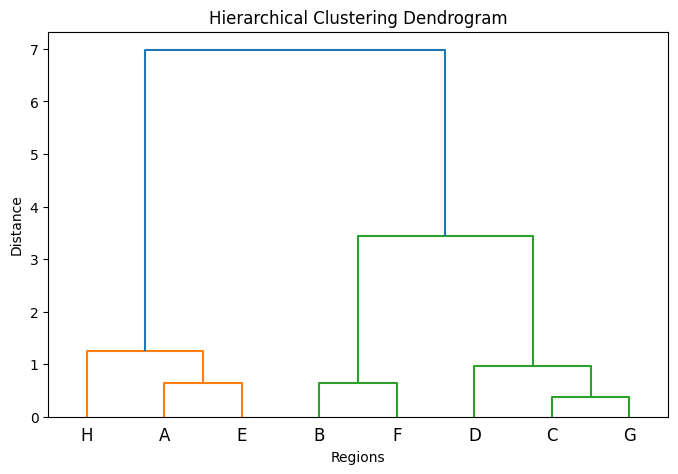

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked, labels=data.index.tolist())
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Regions")
plt.ylabel("Distance")
plt.show()

What this does
Builds a tree (dendrogram) showing:
Which regions are similar
How clusters merge step-by-step

👉 This is something K-Means cannot sho

Step 4: Assign Clusters

In [4]:
from scipy.cluster.hierarchy import fcluster

data["Cluster"] = fcluster(linked, 3, criterion='maxclust')
data

,Vaccination_rate,Access_to_clinics,Mistrust_level,Population_density,Cluster
Region,,,,,
A,85,80,10,1000,1
B,60,50,40,500,2
C,30,20,80,200,3
D,40,30,70,300,3
E,90,85,5,1200,1
F,55,60,50,600,2
G,25,25,85,150,3
H,70,75,20,900,1


What this does
Cuts the tree into 3 clusters
Assigns each region to a group

Why NOT K-Means here?
❌ K-Means limitation
Assumes round/spherical clusters
Forces data into fixed shapes
✅ Hierarchical advantage
Finds natural structure
Works better when:
Patterns are complex
Groups overlap
Healthcare behavior varies

👉 In public health:

Regions are not clean circles
They’re messy, multi-factor patterns

5. Ensuring Clusters Are Reliable
✅ A. Statistical Quality (Silhouette Score)

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, data["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.6419680411695647


Meaning
Measures how well clusters are separated
Range:
Close to 1 → good clusters
Close to 0 → overlapping clusters

B. Clinical / Public Health Validity

👉 Consult with  domain experts:

Example interpretation:

Cluster	Meaning
1	High vaccination, low mistrust
2	Medium access, moderate mistrust
3	Low access + high mistrust
🧠 Key idea

If clusters make sense to doctors/public health teams → valid

C. Stability Over Time

👉 Test:

Run clustering on new data (next month/year)
Check if patterns remain similar
🧠 Why important?
Public health decisions need stable patterns
Not random fluctuations

6. Using Clusters in Practice

Now the powerful part 👇

🏥 A. In Systems (like EHR / dashboards)

Each region gets a cluster label

Example:

Region	Cluster	Meaning
C	3	High risk
A	1	Low risk

B. Dashboard Tracking

Track per cluster:

Vaccination rates
Intervention success
Risk levels

C. Real Decisions
Cluster 3 (High risk)
Low access + high mistrust
👉 Action:
Mobile clinics 🚐
Community outreach
Cluster 2 (Moderate)

👉 Action:

Awareness campaigns
Flexible clinic hours
Cluster 1 (Low risk)

👉 Action:

Maintain current strategy

Simple Intuition
K-Means = “Put people into fixed boxes” 📦
Hierarchical = “Understand how people are related” 🌳

👉 In healthcare → relationships matter more than rigid grouping